In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [ ]:
df = pd.read_csv("C:/Users/dr274/Downloads/diabetes[1].csv")
cols = ["BloodPressure", "BMI", "Insulin", "SkinThickness"]

for i in cols:
    df[i] = df[i].replace(0, np.nan)
print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0           35.0      NaN  33.6   
1            1       85           66.0           29.0      NaN  26.6   
2            8      183           64.0            NaN      NaN  23.3   
3            1       89           66.0           23.0     94.0  28.1   
4            0      137           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


Target: Glucose
Features: BMI, Age, Pregnancies, etc.



In [14]:
X = df[["Age", "Pregnancies","BloodPressure", "Insulin", "SkinThickness"]]
Y = df["BMI"]

#To visualize how the X and Y actually looks like: 
print("This is X:", X.shape)
print("This is Y:", Y.shape)

This is X: (768, 5)
This is Y: (768,)


Text(0, 0.5, 'BMI')

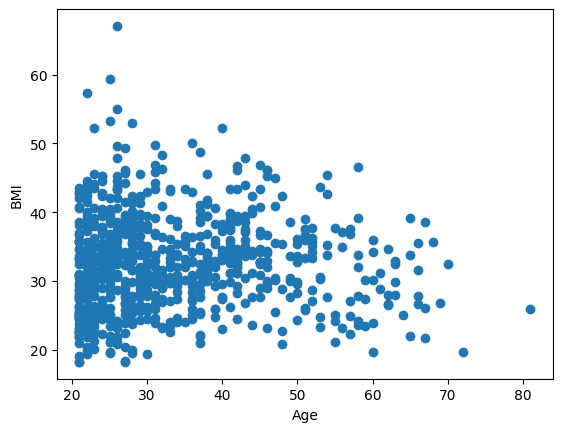

In [15]:
#To better visualize our data we can also plot it using: 
plt.scatter(X["Age"],Y)
plt.xlabel("Age")
plt.ylabel("BMI")

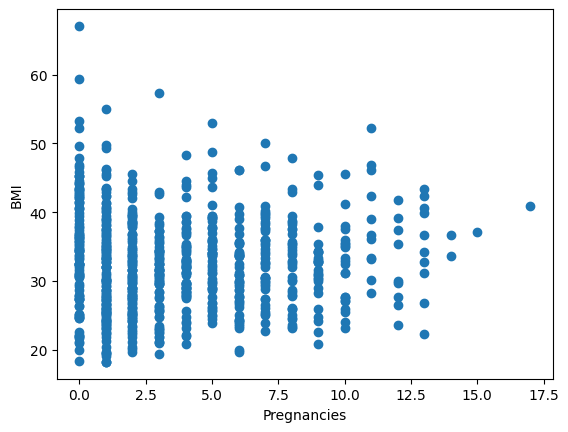

In [18]:
#To better visualize our data we can also plot it using: 
plt.scatter(X["Pregnancies"],Y)
plt.xlabel("Pregnancies")
plt.ylabel("BMI")
plt.show()

Text(0, 0.5, 'BMI')

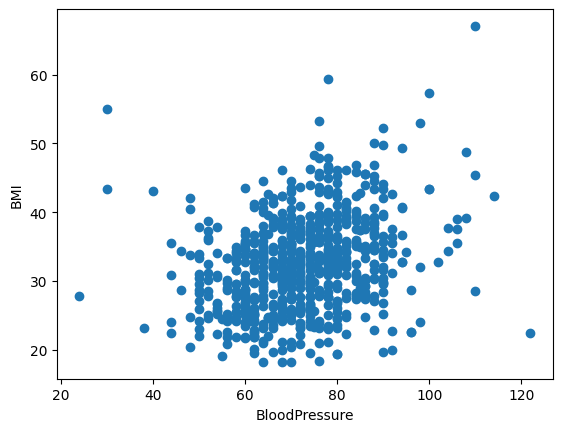

In [17]:
plt.scatter(X["BloodPressure"],Y)
plt.xlabel("BloodPressure")
plt.ylabel("BMI")

To clean our data since there was so many nan values we used: cols = ["BloodPressure", "BMI", "Insulin", "SkinThickness"]

for col in cols:
    df[col] = df[col].replace(0, np.nan)




In [ ]:
#After weve graphed our data and weve cleaned it well start with the actual logic of linear regression: 
# Well be using the mean squared error (mse)

def cost_function(w, b, x, y):
    m = x.shape[0]
    cost_sum = 0.0

    for i in range(m):
        f = np.dot(w, x[i]) + b   # dot product
        cost_sum += (f - y[i])**2

    total_cost = cost_sum / (2 * m)
    return total_cost




In [ ]:
def gradient(w,b,x,y):
    m_samples = x.shape[0]
    #initializing the parcial derivatives
    dc_dw = np.zeros_like(w)
    dc_db = 0 

    for i in range(m_samples):
        f = np.dot(w, x[i]) + b

        dc_dw += (f - y[i]) * x[i]
        dc_db += (f - y[i])
    
    dc_dw = (1/m_samples) * dc_dw 
    dc_db = (1/m_samples) * dc_db

    return dc_db, dc_dw


In [24]:
def gradient_descent(x,y,learning_rate,itterations):
    #initialize our weights and our biasses 
    w = np.zeros(x.shape[1])
    b = 0 

    for i in range(itterations):
       dc_dw, dc_db = gradient(w,b,x,y)

       w = w - learning_rate * dc_dw
       b = b - learning_rate * dc_db

       print(f"Iteration {i}: cost {cost_function(w,b,x,y)}")
        
    return w,b

    